In [1]:
import sys
sys.path.append('../')
import karman
import pandas as pd
import torch
import datetime
import numpy as np
import pickle as pk
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

torch.set_default_dtype(torch.float32)


## First, on the validation/test/train split:

In [2]:
karman_dataset=karman.KarmanDataset(
                            thermo_path='../data/satellites_data_w_sw_2mln.csv',
                            min_date=pd.to_datetime('2000-07-29 00:59:47'),
                            max_date=pd.to_datetime('2024-05-31 23:59:32'),
                            normalization_dict=None,
                            #features_to_exclude_thermo=["all__dates_datetime__",
                            #                            "tudelft_thermo__satellite__",
                            #                            "tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3]",
                            #                            "all__year__[y]",
                            #                            "NRLMSISE00__thermospheric_density__[kg/m**3]"]#add here if there are further features to exlclude
                        )


Creating thermospheric density dataset


Removing from the data errors in mean absolute percentage error 200% or more in the density (between nrlmsise00 and ground truth)
loading it from file
Used features: Index(['tudelft_thermo__altitude__[m]', 'tudelft_thermo__latitude__[deg]',
       'celestrack__ap_average__',
       'space_environment_technologies__f107_obs__',
       'space_environment_technologies__f107_average__',
       'space_environment_technologies__s107_obs__',
       'space_environment_technologies__s107_average__',
       'space_environment_technologies__m107_obs__',
       'space_environment_technologies__m107_average__',
       'space_environment_technologies__y107_obs__',
       'space_environment_technologies__y107_average__', 'JB08__d_st_dt__[K]',
       'tudelft_thermo__longitude__[deg]_sin',
       'tudelft_thermo__longitude__[deg]_cos', 'all__day_of_year__[d]_sin',
       'all__day_of_year__[d]_cos', 'all__seconds_in_day__[s]_sin',
       'all__seconds_in_day__[s]_cos'],
      dtype='object')
Index(['t

In [4]:
import pickle as pk
with open("normalization_dict.pk","wb") as f:
    pk.dump(karman_dataset.normalization_dict,f)

In [5]:
with open("normalization_dict.pk","rb") as f:
    normalization_dict=pk.load(f)

/home/ga00693/mambaforge/envs/karman_gpu/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


In [96]:
karman_model = karman.util.load_model(karman_dataset,
                        model_path='../models/karman_nowcast_model_log_exp_residual_valid_mape_15.14_params_35585.torch',
                        device="cpu",
                        prediction_type="nowcasting",
                        hidden_layer_dims=128,
                        hidden_layers=3
                        )
karman_model.eval()

number of parmaeters: 35585


/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/util.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  karman_model.load_state_dict(torch.load(model_path))


In [95]:
#Train, validation, test splits:
idx_test_fold=2
test_month_idx = 2 * (idx_test_fold - 1)
validation_month_idx = test_month_idx + 2
print(test_month_idx,validation_month_idx)
karman_dataset._set_indices(test_month_idx=[test_month_idx], validation_month_idx=[validation_month_idx],custom={2001: {"validation":2,"test":3},
                                                                                                                    2003: {"validation":9, "test":10},
                                                                                                                    2005: {"validation":4, "test":5},
                                                                                                                    2012: {"validation":8, "test":9},
                                                                                                                    2013: {"validation":4, "test":5},
                                                                                                                    2015: {"validation":2, "test":3},
                                                                                                                    2022: {"validation":0, "test":1},
                                                                                                                    2024: {"validation":3,"test":4}})
train_dataset = karman_dataset.train_dataset()
validation_dataset = karman_dataset.validation_dataset()
test_dataset = karman_dataset.test_dataset()

2 4
Creating training, validation and test sets.


25 years to iterate through.: 100%|██████████| 25/25 [00:06<00:00,  3.96it/s]

Train size: 1641897
Validation size: 162991
Test size: 175278


In [5]:
from torch.utils.data import RandomSampler, SequentialSampler

train_sampler = RandomSampler(train_dataset, num_samples=len(train_dataset))
validation_sampler = RandomSampler(validation_dataset, num_samples=len(validation_dataset))
test_sampler = SequentialSampler(test_dataset)


In [6]:
batch_size = 1024

# And the dataloader
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    pin_memory=False,
    num_workers=0,
    sampler=train_sampler,
    drop_last=True,
)
validation_loader = torch.utils.data.DataLoader(
    validation_dataset,
    batch_size=batch_size,
    pin_memory=False,
    num_workers=0,
    sampler=validation_sampler,
    drop_last=False,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    pin_memory=False,
    num_workers=0,
    sampler=test_sampler,
    drop_last=False,
)

#from here on you can just do the same as `train_base_karman.py` 
# -> predict the density but now while iterating over the test_loader & compare with ground truth


## 2nd Option: 

load a specific set of dates & satellite (e.g. May event):

In [11]:
from torch.utils.data import Subset
dates=pd.to_datetime(karman_dataset.data_thermo['data']['all__dates_datetime__'])
sat_names=karman_dataset.data_thermo['data']['tudelft_thermo__satellite__']
start_date=pd.to_datetime("2024-05-08 00:59:47")
end_date=pd.to_datetime("2024-05-12 23:59:32")
holdout_indices=dates[(dates>start_date) & (dates<end_date) & (sat_names=='swarm_a')].index

karman_dataset_may_2024=Subset(karman_dataset, holdout_indices)

In [12]:
print(list(karman_dataset_may_2024[0].keys()))

['instantaneous_features', 'nrlmsise00', 'exponential_atmosphere', 'target', 'ground_truth', 'ap_average', 'geomagnetic_storm_G_class', 'altitude_bins', 'solar_activity_bins', 'date']


In [13]:
inputs=torch.stack([karman_dataset_may_2024[i]['instantaneous_features'] for i in range(len(karman_dataset_may_2024))])
exponential_atmosphere=torch.stack([karman_dataset_may_2024[i]['exponential_atmosphere'] for i in range(len(karman_dataset_may_2024))])
target=torch.stack([karman_dataset_may_2024[i]['target'] for i in range(len(karman_dataset_may_2024))])

with torch.no_grad():
    out_nn=torch.tanh(karman_model(inputs).flatten())
    out=karman_dataset.scale_density(exponential_atmosphere)+out_nn
#let's extract the density:
density=karman_dataset.unscale_density(out).detach().cpu().numpy()
density_target=karman_dataset.unscale_density(target).detach().cpu().numpy()


In [14]:
len(dates)

2036273

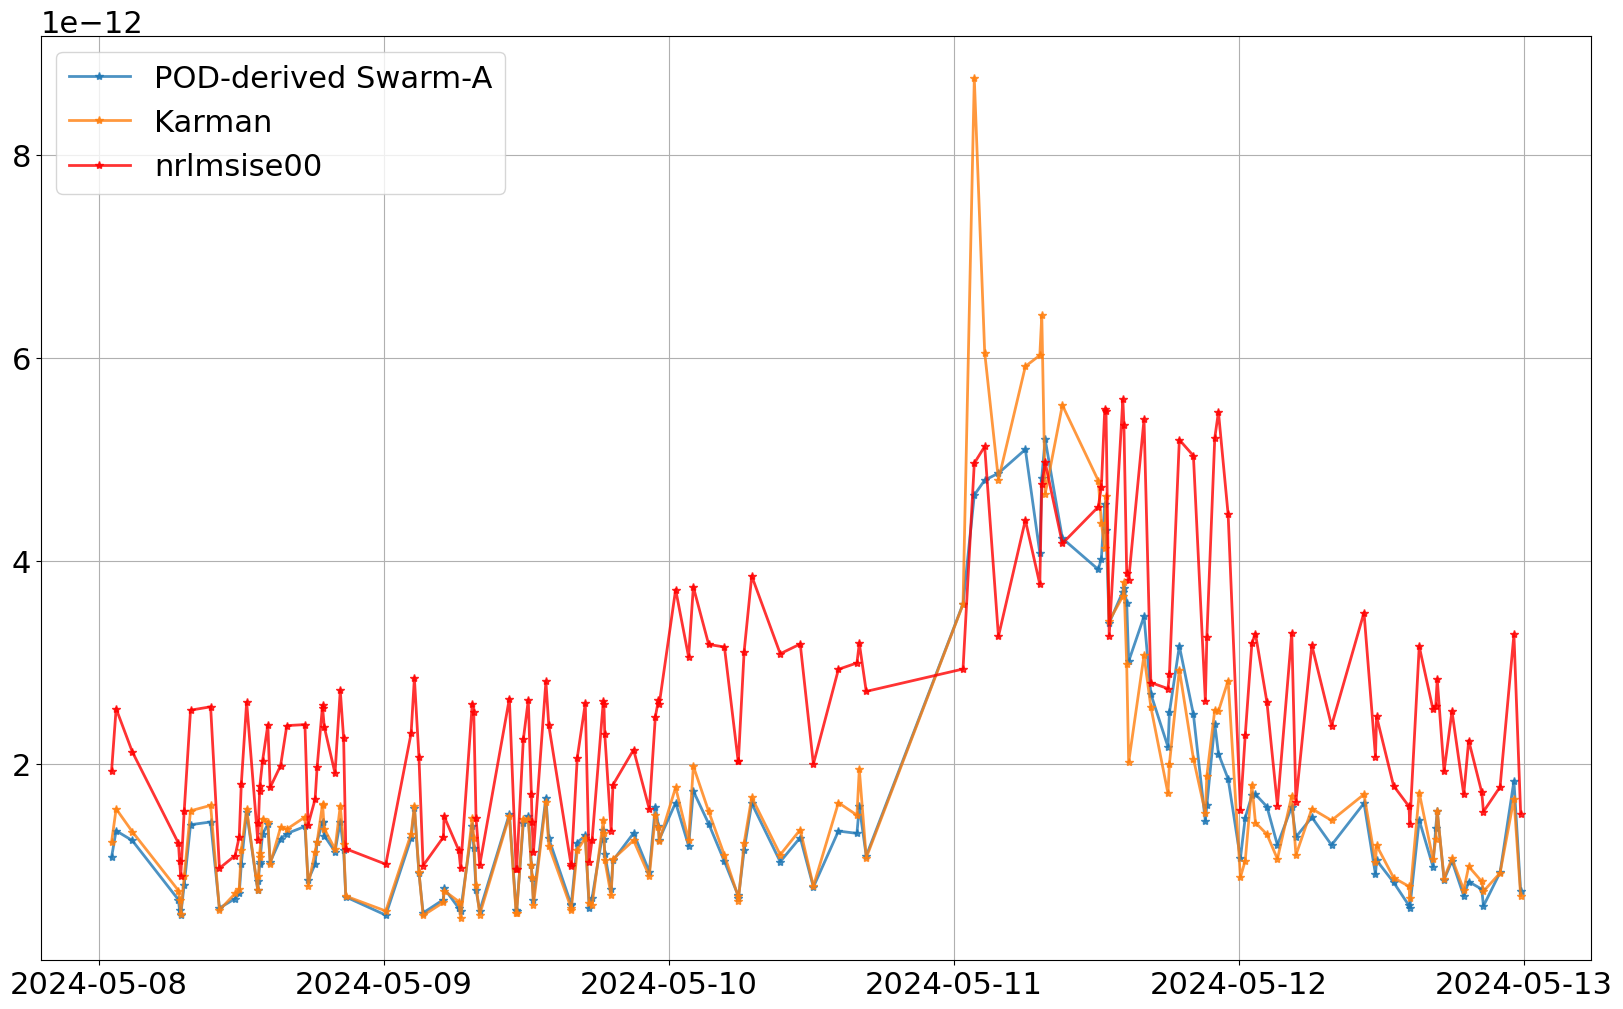

In [15]:
import matplotlib.pyplot as plt
import matplotlib
#change fontsize
matplotlib.rcParams.update({'font.size': 22})
plt.figure(figsize=(20,12))
plt.plot(dates[holdout_indices],
         density_target,
         '-*',
         alpha=0.8,
         label='POD-derived Swarm-A',
         linewidth=2.)
plt.plot(dates[holdout_indices],
         density,
         '-*',
         alpha=0.8,
         label='Karman',
         linewidth=2.)
plt.plot(pd.to_datetime(karman_dataset.data_thermo['data']['all__dates_datetime__'].loc[holdout_indices].values),
         karman_dataset.data_thermo['data']['NRLMSISE00__thermospheric_density__[kg/m**3]'].loc[holdout_indices].values,
         '-*',
         alpha=0.8,
         label='nrlmsise00',
         linewidth=2.,
         color='red')
plt.legend(loc='upper left')
plt.grid()

## 3rd Option - Karman as global nowcasting model

Here we do the inference by creating lat/lon grids and datetimes from scratch, as well as space weather-related inputs, and calling the model.

In [6]:
with open("normalization_dict.pk","rb") as f:
    normalization_dict=pk.load(f)

In [97]:
import pandas as pd

df_thermo=pd.read_parquet('../data_parquet/thermo_subsampled_daily.parquet')

def find_sw_from_thermo(df_thermo, dates):
    # Ensure dates are in the same format
    dates = pd.to_datetime(dates).strftime("%Y-%m-%d")
    
    # Convert the DataFrame's index to a list of dates in 'YYYY-MM-DD' format
    dates_thermo = pd.to_datetime(df_thermo.index).strftime("%Y-%m-%d")
    
    # Create a boolean mask for the rows where the date matches any of the input dates
    mask = dates_thermo.isin(dates)
    
    # Use the mask to filter the DataFrame
    result_df = df_thermo[mask].copy()
    
    # Ensure that repeated dates in the input list are reflected in the result
    result_df = result_df.loc[result_df.index.repeat(dates_thermo[mask].map(dates.value_counts().to_dict()).fillna(0).astype(int))]
    
    return result_df

In [106]:
#the order of the inputs for the nowcasting model is:
# 'tudelft_thermo__altitude__[m]', 
# 'tudelft_thermo__latitude__[deg]',
# 'celestrack__ap_average__',
# 'space_environment_technologies__f107_obs__',
# 'space_environment_technologies__f107_average__',
# 'space_environment_technologies__s107_obs__',
# 'space_environment_technologies__s107_average__',
# 'space_environment_technologies__m107_obs__',
# 'space_environment_technologies__m107_average__',
# 'space_environment_technologies__y107_obs__',
# 'space_environment_technologies__y107_average__', 'JB08__d_st_dt__[K]',
# 'tudelft_thermo__longitude__[deg]_sin',
# 'tudelft_thermo__longitude__[deg]_cos', 'all__day_of_year__[d]_sin',
# 'all__day_of_year__[d]_cos', 'all__seconds_in_day__[s]_sin',
# 'all__seconds_in_day__[s]_cos'

import datetime
def scale_density(density, normalization_dict):
    tmp = torch.log10(density)
    log_min=normalization_dict['log_density']['min']
    log_max=normalization_dict['log_density']['max']
    return 2. * (tmp - log_min) / (log_max - log_min) - 1.

def unscale_density(density_scaled, normalization_dict):
    log_min=normalization_dict['log_density']['min']
    log_max=normalization_dict['log_density']['max']
    tmp=(log_max-log_min)*(density_scaled+1)/2+log_min
    return torch.pow(10,tmp)

from karman.util import exponential_atmosphere
def predict(dates, 
            altitudes,
            longitudes,
            latitudes,
            sw,
            karman_model,
            normalization_dict):
    """
    Performs the inference of the nowcasting model.

    Args:
        - dates (`list`): list of datetime objects
        - altitudes (`list`): list of altitudes (in meters)
        - longitudes (`list`): list of longitudes (in degrees, between -180-180)
        - latitudes (`list`): list of latitudes (in degrees, between -90, 90)
        - thermo_parquet_db (`pandas.DataFrame`): pandas dataframe containing the thermo sw data
        - karman_model (`torch.nn.Module`): the nowcasting model
        - normalization_dict (`dict`): dictionary containing info to normalize the model
    
    Returns:
        - `np.array` predicted density (in kg/m**3)
    """
    sw=find_sw_from_thermo(df_thermo,dates)
    dates=pd.to_datetime(dates)
    doy=torch.tensor(dates.dayofyear,dtype=torch.float32)
    #doy = date.timetuple().tm_yday
    sid = torch.tensor(dates.hour * 3600 + dates.minute * 60 + dates.second + dates.microsecond / 1e6,dtype=torch.float32)
    feature_as_radian = (2* np.pi * (doy-normalization_dict['all__day_of_year__[d]']["min"])/ (normalization_dict['all__day_of_year__[d]']["max"] - normalization_dict['all__day_of_year__[d]']["min"]))
    all_doy_sin=feature_as_radian.sin()
    all_doy_cos=feature_as_radian.cos()

    feature_as_radian = (2* np.pi * (sid-normalization_dict['all__seconds_in_day__[s]']["min"])/ (normalization_dict['all__seconds_in_day__[s]']["max"] - normalization_dict['all__seconds_in_day__[s]']["min"]))
    sid_sin=feature_as_radian.sin()
    sid_cos=feature_as_radian.cos()

    lon=torch.tensor(longitudes)
    lon_sin=torch.deg2rad(lon).sin()
    lon_cos=torch.deg2rad(lon).cos()

    inputs=[]
    alt_n=2*(torch.tensor(altitudes)-normalization_dict['tudelft_thermo__altitude__[m]']["min"])/(normalization_dict['tudelft_thermo__altitude__[m]']["max"]-normalization_dict['tudelft_thermo__altitude__[m]']["min"])-1
    lat_n=2*(torch.tensor(latitudes)-normalization_dict['tudelft_thermo__latitude__[deg]']["min"])/(normalization_dict['tudelft_thermo__latitude__[deg]']["max"]-normalization_dict['tudelft_thermo__latitude__[deg]']["min"])-1
    inputs.append(alt_n)
    inputs.append(lat_n)
    for feature in normalization_dict.keys():
        if feature not in ['all__day_of_year__[d]', 
                           'all__seconds_in_day__[s]', 
                           'tudelft_thermo__longitude__[deg]',
                           'tudelft_thermo__altitude__[m]',
                           'tudelft_thermo__latitude__[deg]',
                           'log_density']:
            try:
                #feature_sw=feature.split('__')[-2]
                inputs.append(2*(torch.tensor(sw[feature].values,dtype=torch.float32)-normalization_dict[feature]["min"])/(normalization_dict[feature]["max"]-normalization_dict[feature]["min"])-1)
            except Exception as e:
                print(f"Note, {feature} not found in the sw dictionary, you have to use: f107_obs, f107_average, s107_obs, s107_average, m107_obs, m107_average, f107_obs, f107_average, ap_average, d_st_dt")
    inputs.append(lon_sin)
    inputs.append(lon_cos)
    inputs.append(all_doy_sin)
    inputs.append(all_doy_cos)
    inputs.append(sid_sin)
    inputs.append(sid_cos)
    inputs=torch.stack(inputs,axis=1)
    expo=exponential_atmosphere(torch.tensor(altitudes)/1e3)
    with torch.no_grad():
        out_nn=torch.tanh(karman_model(inputs).flatten())
        out=scale_density(expo,normalization_dict)+out_nn
    return unscale_density(out,normalization_dict)


In [99]:
# We build the model entries:
n_grid=100
u, v = np.linspace(0, 1, n_grid), np.linspace(0, 1, n_grid)
longitude, latitude = np.sort(2 * np.pi * u), np.sort(np.arccos(2 * v - 1) - np.pi / 2)
lonlat_grid = np.stack([*np.meshgrid(longitude, latitude, indexing="ij")], axis=2).reshape(-1, 2) 

In [121]:

#let's prepare the inputs to the model and run it:
longitudes=list(np.rad2deg(lonlat_grid[:,0],dtype=np.float32))
latitudes=list(np.rad2deg(lonlat_grid[:,1],dtype=np.float32))
n_samples=len(longitudes)
altitudes=[450000.]*n_samples#250km in meters
dates=pd.to_datetime(['2020-05-08 00:59:47']*n_samples)
dates_sw=pd.to_datetime(dates.strftime("%Y-%m-%d"))
sw=find_sw_from_thermo(df_thermo,dates_sw)

In [122]:
density_nn=predict(dates=dates,
                    altitudes=altitudes,
                    longitudes=longitudes,
                    latitudes=latitudes,
                    sw=sw,
                    karman_model=karman_model,
                    normalization_dict=normalization_dict)
density_nn=density_nn.detach().cpu().numpy()

Now the same with NRLMSISE-00:

In [123]:
from nrlmsise00 import msise_flat
date=dates[0]
density_nrlmsise00=msise_flat(
                            time=date,
                            alt=altitudes[0]/1e3,
                            lon=np.rad2deg(lonlat_grid[:, 0]),
                            lat=np.rad2deg(lonlat_grid[:, 1]),
                            f107a=sw['space_environment_technologies__f107_average__'][0],
                            f107=sw['space_environment_technologies__f107_obs__'][0],
                            ap=sw['celestrack__ap_average__'][0],
                        )[:, 5]* 1e3

/var/tmp/ipykernel_3900581/2680309714.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f107a=sw['space_environment_technologies__f107_average__'][0],
/var/tmp/ipykernel_3900581/2680309714.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f107=sw['space_environment_technologies__f107_obs__'][0],
/var/tmp/ipykernel_3900581/2680309714.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ap=sw['celestrack__ap_average__'][0],


In [124]:
min(density_nn),max(density_nn),min(density_nrlmsise00),max(density_nrlmsise00)

(np.float32(5.2508904e-14),
 np.float32(2.190286e-13),
 np.float64(9.970060812276267e-14),
 np.float64(5.509052228616261e-13))

### Plotting:

Please feel free to improve this! --> it currently feels a bit static, would be nice to have GIF (with a rotating Earth), and/or 3D plots on the Earth as well

Average absolute relative percentage error on globe map: 104.75624406806591 %


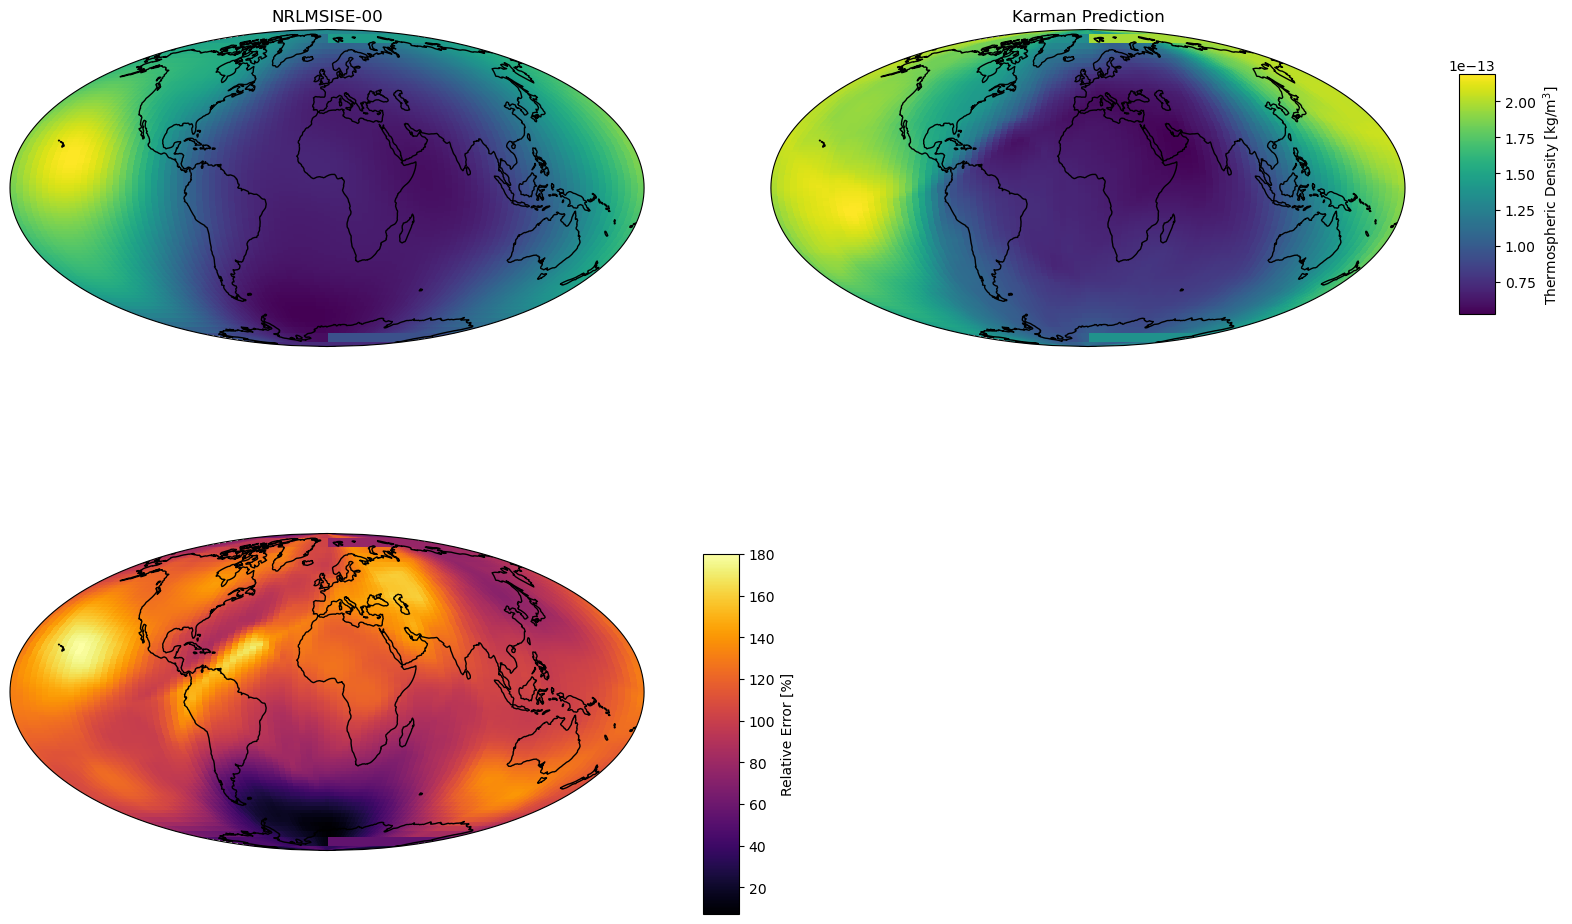

In [125]:
# we setup the longitude x latitude grid, and compute the relative error (in %)
lon_grid = np.rad2deg(lonlat_grid[:, 0].reshape((n_grid, n_grid)))
lat_grid = np.rad2deg(lonlat_grid[:, 1].reshape((n_grid, n_grid)))
rel_err = ((density_nrlmsise00 - density_nn) / density_nn) * 100
# we print to scree the mean absolute percentage error on the globe map:
print(
    f"Average absolute relative percentage error on globe map: {abs(rel_err).mean()} %"
)

# we now create a figure with a globe projection on top:
fig, ax = plt.subplots(
    figsize=(18, 12),
    nrows=2,
    ncols=2,
    subplot_kw={"projection": ccrs.Mollweide(central_longitude=0)},
)
# we flatten the axis and remove the last figure
ax = ax.ravel()
ax[-1].axis("off")

# we plot NRLMSISE-00 on the first figure:
ax[0].pcolormesh(
    lon_grid,
    lat_grid,
    density_nrlmsise00.reshape((n_grid, n_grid)),
    transform=ccrs.PlateCarree(),
    vmin=min(density_nrlmsise00),
    vmax=max(density_nrlmsise00),
)
ax[0].set_global()
ax[0].coastlines()
# ax[0].gridlines()
ax[0].set_title("NRLMSISE-00")

# the NN prediction on the second:
im2 = ax[1].pcolormesh(
    lon_grid,
    lat_grid,
    density_nn.reshape((n_grid, n_grid)),
    transform=ccrs.PlateCarree(),
    vmin=min(density_nn),
    vmax=max(density_nn),
)
ax[1].set_global()
ax[1].coastlines()
# ax[1].gridlines()
ax[1].set_title("Karman Prediction")
# we add a shared colorbar for the first two figures:
cax1 = fig.add_axes([0.93, 0.6, 0.02, 0.2])  # [left, bottom, width, height]
cbar1 = plt.colorbar(im2, orientation="vertical", fraction=0.035, cax=cax1)
cbar1.set_label("Thermospheric Density [kg/m$^3$]")

# we finally plot the relative error in the second row
im3 = ax[2].pcolormesh(
    lon_grid,
    lat_grid,
    rel_err.reshape((n_grid, n_grid)),
    transform=ccrs.PlateCarree(),
    cmap="inferno",
)
ax[2].set_global()
ax[2].coastlines()

# and we add the colorbar for that:
cax2 = fig.add_axes([0.51, 0.1, 0.02, 0.3])  # [left, bottom, width, height]
cbar1 = plt.colorbar(im3, orientation="vertical", fraction=0.035, cax=cax2)
cbar1.set_label("Relative Error [%]")